<a href="https://colab.research.google.com/github/ambermartin-data-lab/healthfirst-data-analytics-academy-2025-2026/blob/main/Project_3_NYARRESTdataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#NYPD ARREST ANALYSIS
##Comparing Arrest Trends by Borough

**Project Goal**

The goal of this project is to analyze NYPD arrest data and compare arrest trends between two New York City boroughs.

For my analysis, I selected:
- Brooklyn
_ Manhattan

The analysis includes:
- Data cleaning
- Descriptive statistics
- Visualizations
- Borough comparison


**Import Libraries**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

**Upload Data File**

In [3]:
#Upload file
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')


Saving NYPD_Arrest_Data_(Year_to_Date)_20260506.csv to NYPD_Arrest_Data_(Year_to_Date)_20260506.csv
User uploaded file "NYPD_Arrest_Data_(Year_to_Date)_20260506.csv" with length 15373670 bytes


**Load Dataset and Explore data**

In [5]:
df = pd.read_csv('/content/NYPD_Arrest_Data_(Year_to_Date)_20260506.csv')
df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,318451126,01/06/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,M,BLACK,1020232,210719,40.744989,-73.870145,POINT (-73.870145 40.744989)
1,318308486,01/03/2026,203.0,"TRESPASS 3, CRIMINAL",352.0,CRIMINAL TRESPASS,PL 140100G,M,K,77,1,25-44,M,BLACK,1003358,182945,40.668798,-73.931120,POINT (-73.93112014 40.66879784)
2,318550123,01/08/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,48,0,25-44,M,WHITE HISPANIC,1011780,246837,40.844152,-73.900500,POINT (-73.9005 40.844152)
3,318580867,01/07/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102B,F,M,28,0,(null),(null),BLACK,999788,233328,40.807102,-73.943874,POINT (-73.943874 40.807102)
4,318684449,01/10/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,B,45,0,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401)


In [6]:
df.shape

(69305, 19)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69305 entries, 0 to 69304
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ARREST_KEY         69305 non-null  int64  
 1   ARREST_DATE        69305 non-null  object 
 2   PD_CD              69303 non-null  float64
 3   PD_DESC            69305 non-null  object 
 4   KY_CD              69293 non-null  float64
 5   OFNS_DESC          69305 non-null  object 
 6   LAW_CODE           69305 non-null  object 
 7   LAW_CAT_CD         69038 non-null  object 
 8   ARREST_BORO        69305 non-null  object 
 9   ARREST_PRECINCT    69305 non-null  int64  
 10  JURISDICTION_CODE  69305 non-null  int64  
 11  AGE_GROUP          69305 non-null  object 
 12  PERP_SEX           69305 non-null  object 
 13  PERP_RACE          69305 non-null  object 
 14  X_COORD_CD         69305 non-null  int64  
 15  Y_COORD_CD         69305 non-null  int64  
 16  Latitude           693

**Data Cleaning**

In [8]:
# Removing missing borough values
df = df.dropna(subset=['ARREST_BORO'])

In [9]:
# Removing duplicate rows
df = df.drop_duplicates()

Data cleaning is important because missing or duplicate values can affect the accuracy of the analysis.

In this step:
- Missing borough values were removed
- Duplicate rows were removed

In [21]:
#Filtering by Age group, perp sex and borough to compare arrest between Brookly and Manhattan.

# Replace string '(null)' with actual NaN values in 'AGE_GROUP' and 'PERP_SEX' columns
df['AGE_GROUP'] = df['AGE_GROUP'].replace('(null)', np.nan)
df['PERP_SEX'] = df['PERP_SEX'].replace('(null)', np.nan)

# Verify the changes
print("Missing values in 'AGE_GROUP' after cleaning:")
print(df['AGE_GROUP'].isnull().sum())
print("\nMissing values in 'PERP_SEX' after cleaning:")
print(df['PERP_SEX'].isnull().sum())

# Keep the original filtering for brooklyn_df and manhattan_df
brooklyn_df = df[df['ARREST_BORO'] == 'BROOKLYN']
manhattan_df = df[df['ARREST_BORO'] == 'MANHATTAN']

Missing values in 'AGE_GROUP' after cleaning:
16933

Missing values in 'PERP_SEX' after cleaning:
16933


There are 16,933 missing values in both AGE_GROUP and PERP_SEX columns. Which mean that for 16,933 arrest records, the age group and perpetrator sex information was initially recorded as (null).

In [22]:
count_byboro = df['ARREST_BORO'].value_counts()
print(count_byboro)

ARREST_BORO
K    21111
M    15870
B    15613
Q    14160
S     2551
Name: count, dtype: int64


This output shows the count of arrests for each borough, sorted in descending order of arrests.

*   K (Brooklyn): 21,111 arrests
*   M (Manhattan): 15,870 arrests
*   B (Bronx): 15,613 arrests
*   Q (Queens): 14,160 arrests
*   S (Staten Island): 2,551 arrests


In [23]:
# Dropping rows with missing values in AGE_GROUP and PERP_SEX columns.
brooklyn_df = brooklyn_df.dropna(subset=['AGE_GROUP', 'PERP_SEX'])
manhattan_df = manhattan_df.dropna(subset=['AGE_GROUP', 'PERP_SEX'])

In [27]:
print(f"Shape of brooklyn_df after dropping NaNs: {brooklyn_df.shape}")
print(f"Shape of manhattan_df after dropping NaNs: {manhattan_df.shape}")

Shape of brooklyn_df after dropping NaNs: (0, 19)
Shape of manhattan_df after dropping NaNs: (0, 19)


Since the borough-specific dataframes are empty after dropping NaNs, we will continue with the descriptive statistics on the main `df` to get an overall understanding of the arrest data. Then, we can re-evaluate how to best compare boroughs, perhaps by imputing missing values or analyzing other columns.

#Descriptive Statistics

Descriptive statistics summarize and organize the data so patterns and trends can be identified.

In [28]:
df.describe(include='all')

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
count,6.930500e+04,69305,69303.000000,69305,69293.000000,69305,69305,69038,69305,69305.000000,69305.000000,52372,52372,69305,6.930500e+04,69305.000000,69305.000000,69305.000000,69305
unique,NaN,90,NaN,216,NaN,55,778,6,5,NaN,NaN,5,2,7,NaN,NaN,NaN,NaN,18230
top,NaN,03/11/2026,NaN,ASSAULT 3,NaN,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,K,NaN,NaN,25-44,M,BLACK,NaN,NaN,NaN,NaN,POINT (-73.88151 40.671413)
freq,NaN,1078,NaN,7036,NaN,9415,6881,40761,21111,NaN,NaN,30798,42719,33340,NaN,NaN,NaN,NaN,508
mean,3.204493e+08,NaN,458.246786,NaN,262.637741,NaN,NaN,NaN,NaN,63.387634,0.899690,NaN,NaN,NaN,1.005511e+06,207575.198485,40.736418,-73.922995,NaN
std,1.309817e+06,NaN,279.603446,NaN,149.718811,NaN,NaN,NaN,NaN,34.077372,6.560605,NaN,NaN,NaN,2.229968e+04,29859.100884,0.081820,0.074304,NaN
min,3.182079e+08,NaN,9.000000,NaN,101.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,-7.400000e+01,40.000000,40.505195,-74.253049,NaN
25%,3.193060e+08,NaN,199.000000,NaN,117.000000,NaN,NaN,NaN,NaN,40.000000,0.000000,NaN,NaN,NaN,9.907960e+05,184962.000000,40.674266,-73.976437,NaN
50%,3.204358e+08,NaN,439.000000,NaN,341.000000,NaN,NaN,NaN,NaN,66.000000,0.000000,NaN,NaN,NaN,1.005390e+06,204948.000000,40.729067,-73.923689,NaN
75%,3.215846e+08,NaN,744.000000,NaN,344.000000,NaN,NaN,NaN,NaN,90.000000,0.000000,NaN,NaN,NaN,1.017119e+06,236070.000000,40.814611,-73.881510,NaN


### Visualizing Arrest Trends

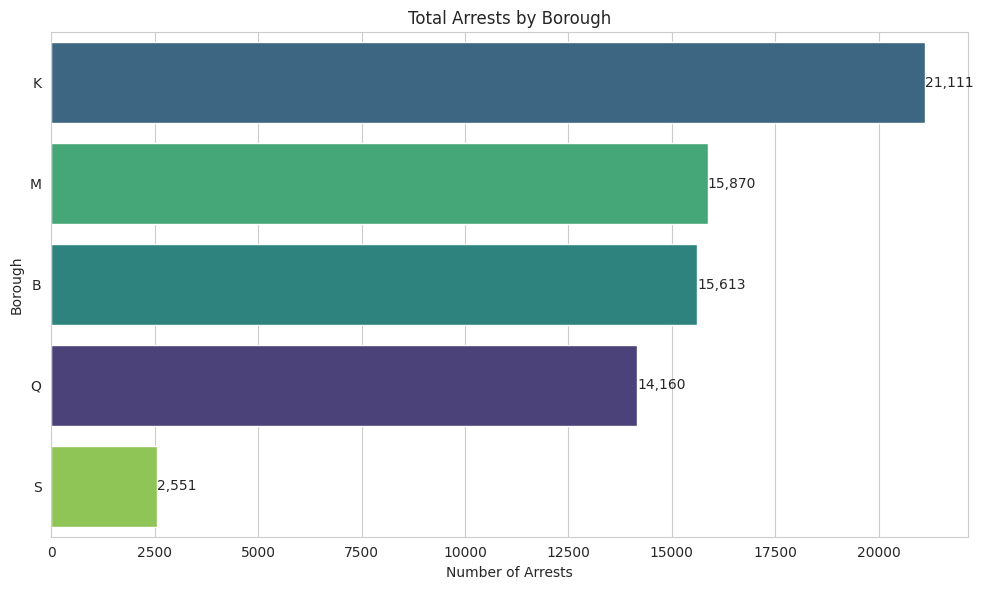

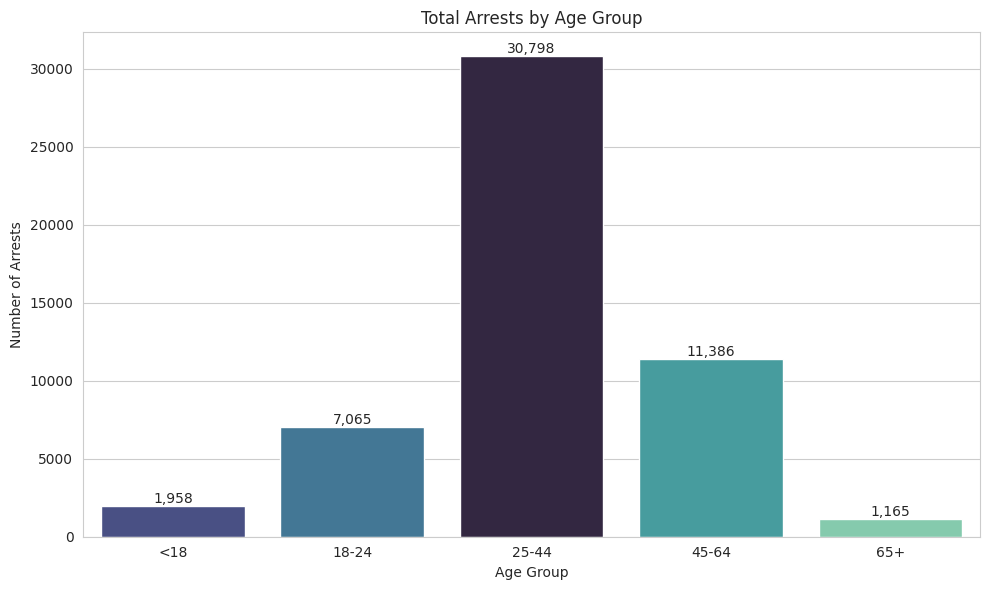

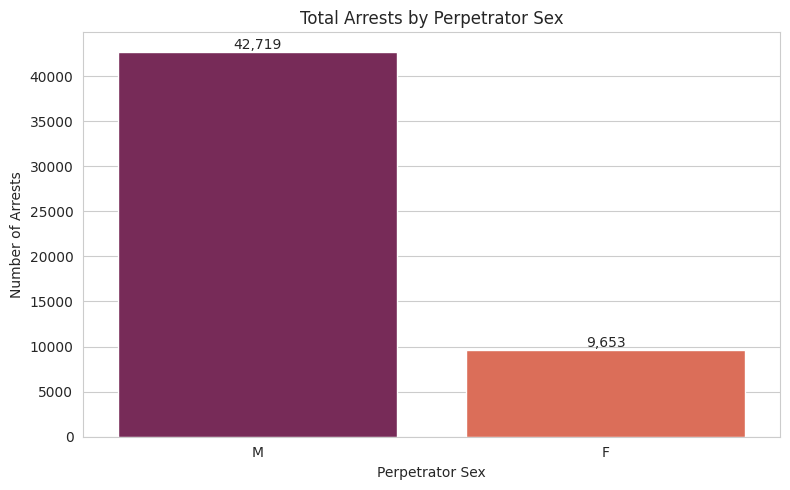

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style('whitegrid')

# Plot 1: Arrests by Borough
plt.figure(figsize=(10, 6))
ax1 = sns.countplot(y='ARREST_BORO', data=df, order=df['ARREST_BORO'].value_counts().index, palette='viridis', hue='ARREST_BORO', legend=False)
plt.title('Total Arrests by Borough')
plt.xlabel('Number of Arrests')
plt.ylabel('Borough')

# Add counts on the bars with comma formatting
for container in ax1.containers:
    ax1.bar_label(container, fmt='{:,.0f}')

plt.tight_layout()
plt.show()

# Plot 2: Arrests by Age Group
# Drop NaN values for plotting age group to avoid displaying 'NaN' as a category
age_group_data = df.dropna(subset=['AGE_GROUP'])
plt.figure(figsize=(10, 6))
ax2 = sns.countplot(x='AGE_GROUP', data=age_group_data, order=['<18', '18-24', '25-44', '45-64', '65+'], palette='mako', hue='AGE_GROUP', legend=False)
plt.title('Total Arrests by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Arrests')

# Add counts on the bars with comma formatting
for container in ax2.containers:
    ax2.bar_label(container, fmt='{:,.0f}')

plt.tight_layout()
plt.show()

# Plot 3: Arrests by Perpetrator Sex
# Drop NaN values for plotting perpetrator sex
perp_sex_data = df.dropna(subset=['PERP_SEX'])
plt.figure(figsize=(8, 5))
ax3 = sns.countplot(x='PERP_SEX', data=perp_sex_data, palette='rocket', hue='PERP_SEX', legend=False)
plt.title('Total Arrests by Perpetrator Sex')
plt.xlabel('Perpetrator Sex')
plt.ylabel('Number of Arrests')

# Add counts on the bars with comma formatting
for container in ax3.containers:
    ax3.bar_label(container, fmt='{:,.0f}')

plt.tight_layout()
plt.show()

### Relationship Between Offense Description and Age Group

In [39]:
# Analyze the relationship between OFNS_DESC and AGE_GROUP
# First, drop rows where AGE_GROUP or OFNS_DESC is NaN, as these are not relevant for this analysis
offense_age_data = df.dropna(subset=['AGE_GROUP', 'OFNS_DESC']).copy()

# Group by offense description and age group, then count occurrences
offense_by_age = offense_age_data.groupby(['OFNS_DESC', 'AGE_GROUP']).size().reset_index(name='Count')

# Display the top combinations to get an initial idea
display(offense_by_age.sort_values(by='Count', ascending=False).head(10))

,OFNS_DESC,AGE_GROUP,Count
19,ASSAULT 3 & RELATED OFFENSES,25-44,4438
69,FELONY ASSAULT,25-44,2807
185,PETIT LARCENY,25-44,2735
126,MISCELLANEOUS PENAL LAW,25-44,2491
51,DANGEROUS DRUGS,25-44,2470
224,VEHICLE AND TRAFFIC LAWS,25-44,1763
186,PETIT LARCENY,45-64,1637
20,ASSAULT 3 & RELATED OFFENSES,45-64,1513
41,CRIMINAL MISCHIEF & RELATED OF,25-44,1494
52,DANGEROUS DRUGS,45-64,1409


To better visualize the distribution, let's create a pivot table and then a heatmap.

I leveraged Gemini for heat map analysis

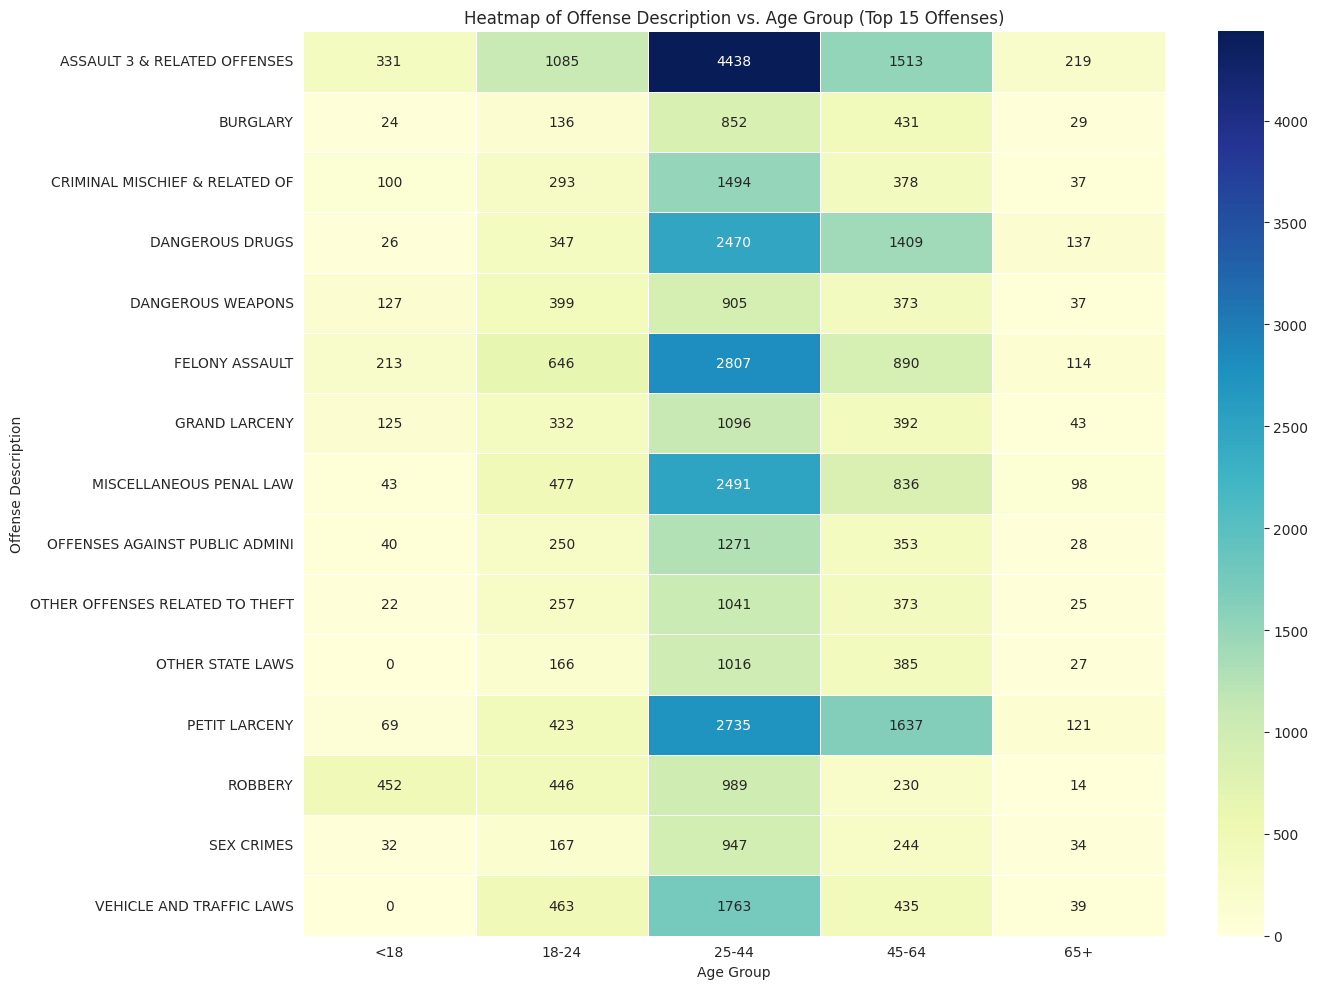

In [45]:
# Pivot the table to prepare for heatmap visualization
# Select the top 15 offense descriptions for clarity in visualization
top_offenses = offense_by_age.groupby('OFNS_DESC')['Count'].sum().nlargest(15).index
filtered_offense_by_age = offense_by_age[offense_by_age['OFNS_DESC'].isin(top_offenses)]

pivot_table = filtered_offense_by_age.pivot_table(index='OFNS_DESC', columns='AGE_GROUP', values='Count', fill_value=0)

# Ensure the age groups are in order
age_group_order = ['<18', '18-24', '25-44', '45-64', '65+']
# Reindex columns to ensure correct order and handle cases where an age group might be missing
pivot_table = pivot_table.reindex(columns=[col for col in age_group_order if col in pivot_table.columns], fill_value=0)

# Create the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=.5)
plt.title('Heatmap of Offense Description vs. Age Group (Top 15 Offenses)')
plt.xlabel('Age Group')
plt.ylabel('Offense Description')
plt.tight_layout()
plt.show()

### Comparing Arrest Trends: Brooklyn vs. Manhattan

In [46]:
# Re-filter the main DataFrame for Brooklyn and Manhattan, avoiding the previous issue of dropping all rows.
brooklyn_df = df[df['ARREST_BORO'] == 'K'].copy() # 'K' for Brooklyn
manhattan_df = df[df['ARREST_BORO'] == 'M'].copy() # 'M' for Manhattan

print(f"Number of arrests in Brooklyn: {len(brooklyn_df)}")
print(f"Number of arrests in Manhattan: {len(manhattan_df)}")

Number of arrests in Brooklyn: 21111
Number of arrests in Manhattan: 15870


Now, let's visualize the distribution of offenses, age groups, and perpetrator sex for both boroughs to identify differences.

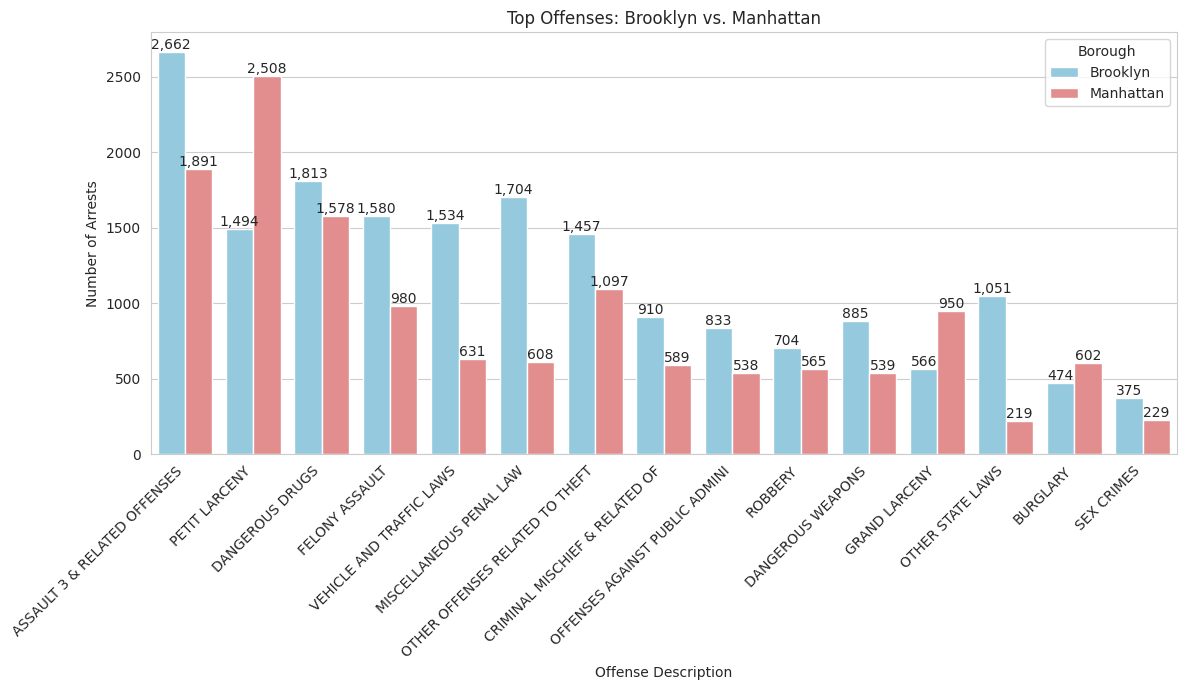

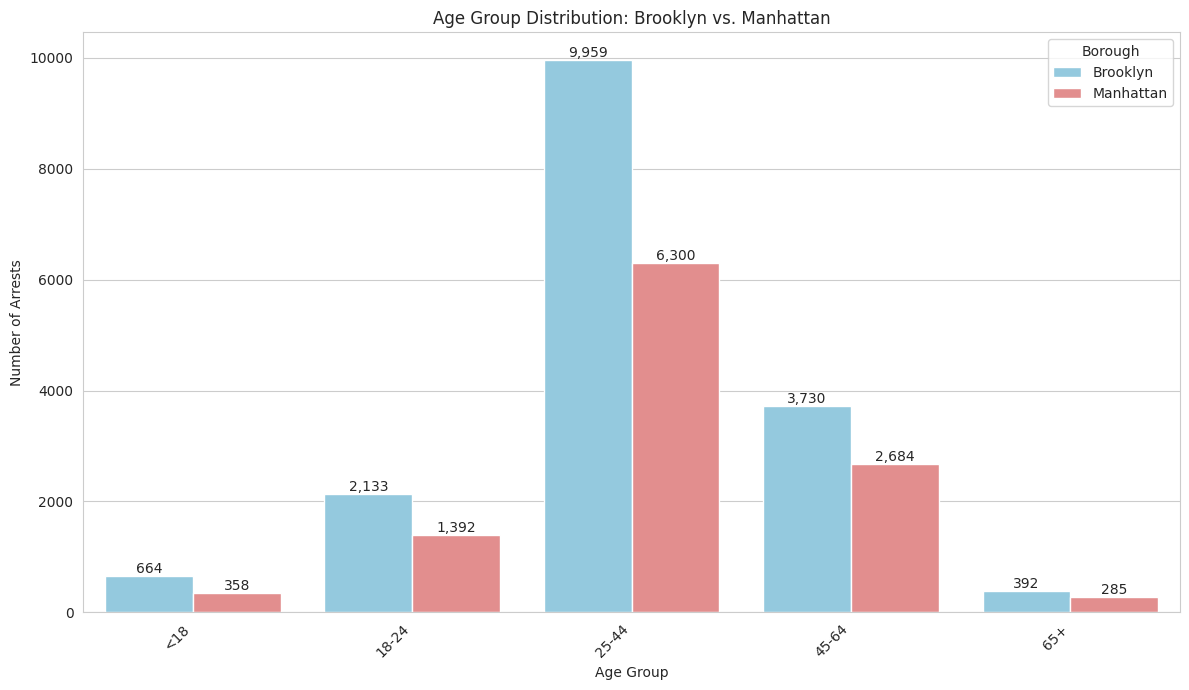

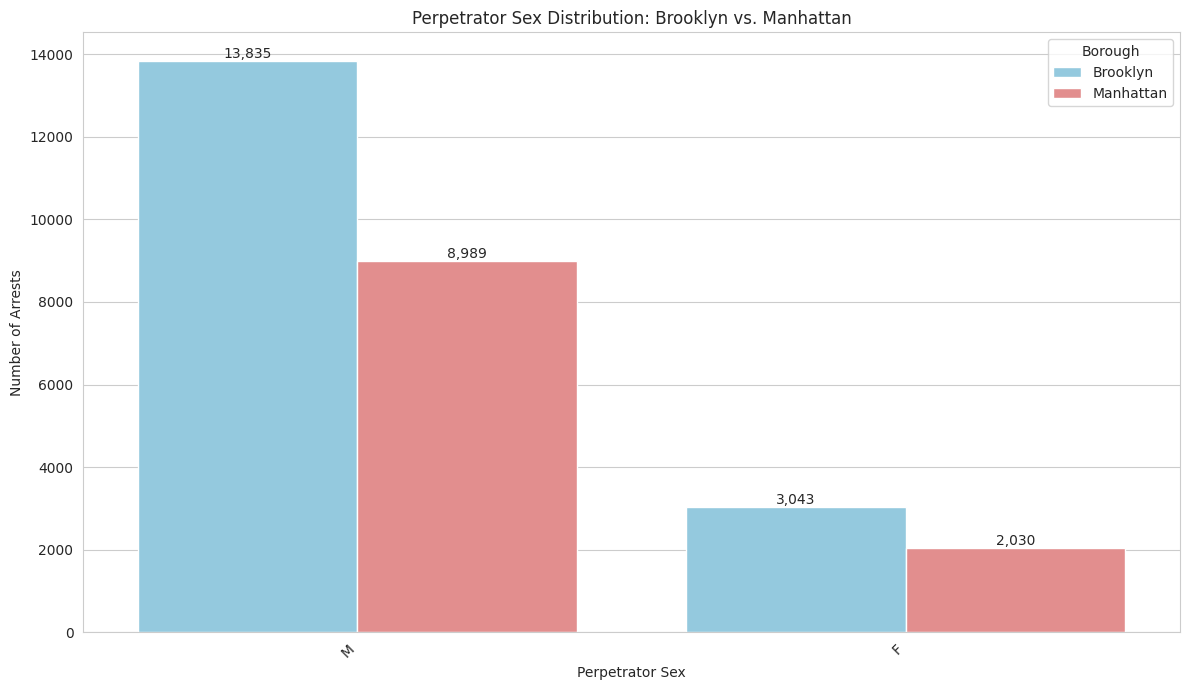

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot comparative bar charts for boroughs
def plot_borough_comparison(data_brooklyn, data_manhattan, column, title, x_label, y_label, order=None):
    plt.figure(figsize=(12, 7))

    # Combine data for plotting, useful for consistent ordering and palettes
    combined_data = pd.concat([data_brooklyn[[column, 'ARREST_BORO']], data_manhattan[[column, 'ARREST_BORO']]])

    ax = sns.countplot(data=combined_data.dropna(subset=[column]),
                  x=column,
                  hue='ARREST_BORO',
                  order=order if order is not None else combined_data[column].value_counts().index,
                  palette={'K': 'skyblue', 'M': 'lightcoral'})

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Borough', labels=['Brooklyn', 'Manhattan'])

    # Add counts on the bars with comma formatting
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}')

    plt.tight_layout()
    plt.show()

# Comparison 1: Offense Description
# Get top 10 offenses for better visualization
top_10_offenses_brooklyn = brooklyn_df['OFNS_DESC'].value_counts().nlargest(10).index
top_10_offenses_manhattan = manhattan_df['OFNS_DESC'].value_counts().nlargest(10).index

# Combine and sort unique top offenses for consistent plotting order
all_top_offenses = pd.Index(list(top_10_offenses_brooklyn) + list(top_10_offenses_manhattan)).unique()
# Reorder based on overall frequency if desired, or keep as is

plot_borough_comparison(brooklyn_df, manhattan_df, 'OFNS_DESC',
                        'Top Offenses: Brooklyn vs. Manhattan',
                        'Offense Description', 'Number of Arrests',
                        order=df['OFNS_DESC'].value_counts().nlargest(15).index)

# Comparison 2: Age Group
age_group_order = ['<18', '18-24', '25-44', '45-64', '65+']
plot_borough_comparison(brooklyn_df, manhattan_df, 'AGE_GROUP',
                        'Age Group Distribution: Brooklyn vs. Manhattan',
                        'Age Group', 'Number of Arrests',
                        order=age_group_order)

# Comparison 3: Perpetrator Sex
plot_borough_comparison(brooklyn_df, manhattan_df, 'PERP_SEX',
                        'Perpetrator Sex Distribution: Brooklyn vs. Manhattan',
                        'Perpetrator Sex', 'Number of Arrests')

#Project Summary

In this project, I analyzed NYPD arrest data to identify trends and patterns across New York City boroughs. I compared arrest activity between Brooklyn and Manhattan while exploring factors such as age group, gender, and offense type.

During the analysis, I found that Brooklyn had the highest number of arrests with 21,111 arrests, while Manhattan had 15,870 arrests. The dataset contained over 69,000 arrest records, which provided a strong amount of data for analysis.

I also discovered that there were 16,933 missing values in both the AGE_GROUP and PERP_SEX columns, which highlighted the importance of data cleaning before performing analysis. Using descriptive statistics, heatmaps, and bar charts helped make the trends easier to understand and visualize.

Overall, this project strengthened my skills in Python, data cleaning, exploratory data analysis, and data visualization while teaching me how to turn raw data into meaningful insights.